K-Means คือการ "แบ่งกลุ่มลูกค้า" โดยที่เราไม่ต้องบอกล่วงหน้าว่าใครอยู่กลุ่มไหน model จะหาเองจากความคล้ายกันของ RFM ลองนึกภาพว่าโยนลูกค้า 500 คนลงบนกระดาษ แล้ววาดวงกลมล้อมรอบกลุ่มที่ "ใกล้กัน" — นั่นคือสิ่งที่ K-Means ทำ

# Normalize

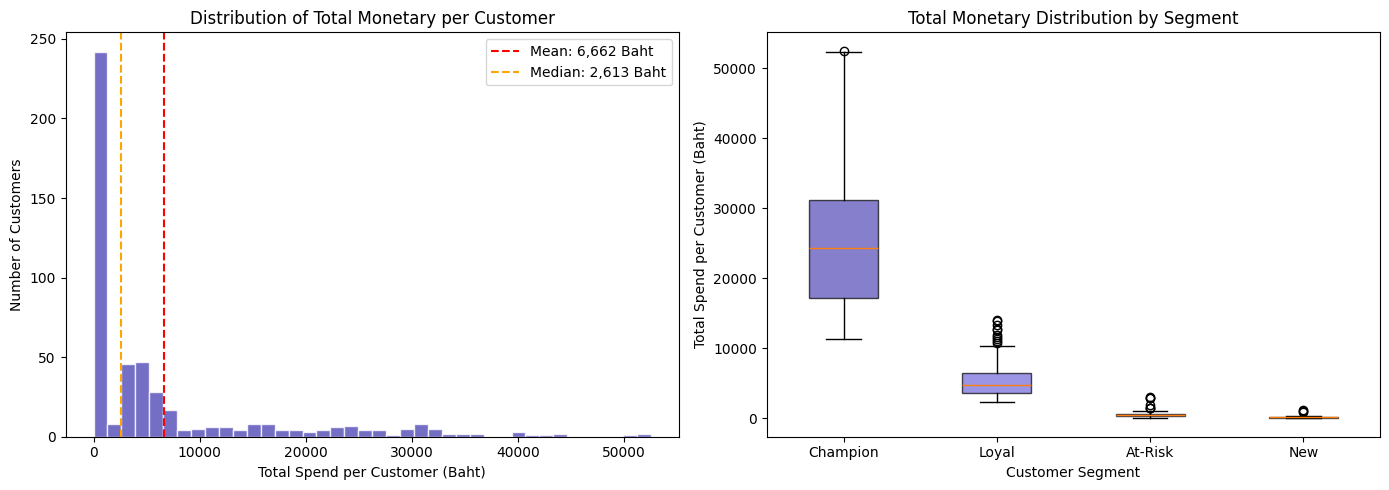

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📥 1. โหลดข้อมูล (เวอร์ชันเปิดตรงจากโฟลเดอร์หลัก)
rfm = pd.read_csv('rfm_features.csv')
customer = pd.read_csv('customer_master.csv')

# --- 2. เชื่อมข้อมูล ---
rfm_merged = rfm.merge(customer[['customer_id', 'true_segment']], on='customer_id')
seg_order = ['Champion', 'Loyal', 'At-Risk', 'New']
data_box = [rfm_merged[rfm_merged['true_segment'] == s]['monetary'].values for s in seg_order]

# 3. สร้างผืนผ้าใบแฝด
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# [กราฟฝั่งซ้าย] : แก้ไขจากคำว่า "บาท" เป็น "Baht" เพื่อไม่ให้ฟอนต์แตก
# ==========================================
axes[0].hist(rfm['monetary'], bins=40, color='#534AB7', edgecolor='white', alpha=0.8)

axes[0].axvline(rfm['monetary'].mean(), color='red', linestyle='--',
                label=f'Mean: {rfm["monetary"].mean():,.0f} Baht')
axes[0].axvline(rfm['monetary'].median(), color='orange', linestyle='--',
                label=f'Median: {rfm["monetary"].median():,.0f} Baht')

axes[0].legend()
axes[0].set_title('Distribution of Total Monetary per Customer')
axes[0].set_xlabel('Total Spend per Customer (Baht)')
axes[0].set_ylabel('Number of Customers')

# ==========================================
# [กราฟฝั่งขวา] : Boxplot แยกตาม Customer Segment
# ==========================================
bp = axes[1].boxplot(data_box, tick_labels=seg_order, patch_artist=True)
COLORS = ['#534AB7', '#7369DB', '#948BFA', '#C4BFFF']
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Total Monetary Distribution by Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Total Spend per Customer (Baht)')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

features = ['recency', 'frequency', 'monetary']
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm[features])

In [19]:
import pandas as pd

# 💡 แปลง NumPy array (X_scaled) ให้เป็น DataFrame ก่อนใช้งาน
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# คราวนี้จะสามารถรันตรวจสอบค่า Mean และ Std ได้ตามปกติแล้วครับ
print(X_scaled_df.mean().round(4))  # ควรได้ ~0.0000
print(X_scaled_df.std().round(4))   # ควรได้ ~1.0000

recency      0.0
frequency    0.0
monetary    -0.0
dtype: float64
recency      1.001
frequency    1.001
monetary     1.001
dtype: float64


# หา k ที่เหมาะสม ด้วย 2 วิธีพร้อมกัน

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. เตรียมพื้นที่เก็บค่า Metric ทั้ง 2 รูปแบบ
inertias = []
sil_scores = []

# 2. วนลูปคำนวณค่า k ตั้งแต่ 2 ถึง 8
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    # บันทึกค่าจาก Elbow Method (Inertia)
    inertias.append(km.inertia_)

    # บันทึกค่าจาก Silhouette Score
    sil_scores.append(silhouette_score(X_scaled, labels))

print("✅ คำนวณ Metric ทั้ง 2 วิธีเสร็จเรียบร้อยแล้ว!")

✅ คำนวณ Metric ทั้ง 2 วิธีเสร็จเรียบร้อยแล้ว!


โค้ดสำหรับพล็อตกราฟเปรียบเทียบ

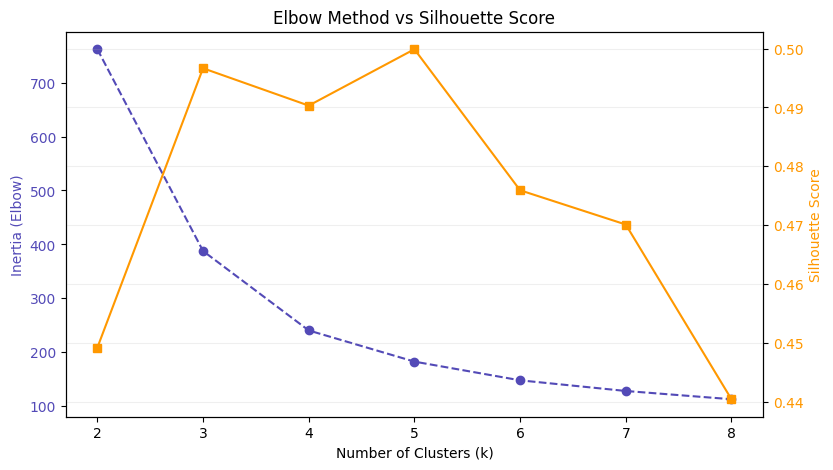

In [22]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 5))

# พล็อตกราฟเส้นฝั่งซ้าย (Inertia - เส้นสีม่วง)
color = '#534AB7'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color)
ax1.plot(range(2, 9), inertias, marker='o', color=color, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# พล็อตกราฟเส้นฝั่งขวา (Silhouette Score - เส้นสีส้ม)
ax2 = ax1.twinx()
color = '#FF9800'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(range(2, 9), sil_scores, marker='s', color=color, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method vs Silhouette Score')
plt.grid(True, alpha=0.2)
plt.show()

รัน K-Means จริงด้วย $k=4$

In [24]:
from sklearn.cluster import KMeans

# 1. เทรนโมเดลจริงด้วยจำนวนกลุ่ม k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. ทำการพยากรณ์กลุ่ม และสร้างคอลัมน์ 'cluster' เก็บไว้ในตาราง rfm หลักของเรา
rfm['cluster'] = kmeans_final.fit_predict(X_scaled)

# 3. ดูจำนวนลูกค้าที่ถูกจัดเข้าไปในแต่ละกลุ่ม (0, 1, 2, 3)
print("=== จำนวนลูกค้าในแต่ละ Cluster ===")
print(rfm['cluster'].value_counts().sort_index())

# ลองแอบส่องหน้าตาตารางหลังจากได้กลุ่มแล้ว
rfm.head()

=== จำนวนลูกค้าในแต่ละ Cluster ===
cluster
0    146
1     65
2    165
3    124
Name: count, dtype: int64


,customer_id,recency,frequency,monetary,cluster
0,C0001,112,1,252.55,3
1,C0002,3,6,3157.74,2
2,C0003,24,10,5297.44,2
3,C0004,141,1,15.85,3
4,C0005,25,8,4229.73,2


,customer_count,avg_recency,avg_frequency,avg_monetary
cluster,,,,
0,146,31.1,2.4,758.6
1,65,13.7,14.6,29873.6
2,165,22.1,8.5,7462.7
3,124,113.8,1.6,378.2


ตั้งชื่อ Segment จาก Profile

In [28]:
# ===================================================
# 🤖 ระบบค้นหาและแปะป้ายชื่อ Segment อัตโนมัติ (No Hardcode!)
# ===================================================

# สร้าง Dictionary เปล่าเตรียมไว้เก็บค่าที่ระบบค้นหาเจอ
cluster_map = {}

# 1. ค้นหา At-Risk : กลุ่มที่มีค่าเฉลี่ย Recency สูงที่สุด (หายไปนานที่สุด)
at_risk_cluster = cluster_profile['avg_recency'].idxmax()
cluster_map[at_risk_cluster] = 'At-Risk'

# ดึงคลัสเตอร์ที่เหลือออกมาพิจารณาต่อ เพื่อไม่ให้ซ้ำซ้อนกัน
remaining_clusters = [c for c in cluster_profile.index if c != at_risk_cluster]

# 2. ค้นหา Champion : จากคลัสเตอร์ที่เหลือ กลุ่มไหนมียอดซื้อ (Monetary) เฉลี่ยสูงสุด
champion_cluster = cluster_profile.loc[remaining_clusters, 'avg_monetary'].idxmax()
cluster_map[champion_cluster] = 'Champion'

# ค้นหาคลัสเตอร์ที่เหลืออีก 2 กลุ่ม
remaining_clusters = [c for c in remaining_clusters if c != champion_cluster]

# 3. ค้นหา New : จาก 2 กลุ่มที่เหลือ กลุ่มไหนมียอดซื้อ (Monetary) เฉลี่ยต่ำที่สุด (เพิ่งซื้อน้อย)
new_cluster = cluster_profile.loc[remaining_clusters, 'avg_monetary'].idxmin()
cluster_map[new_cluster] = 'New'

# 4. ค้นหา Loyal : คลัสเตอร์สุดท้ายที่เหลืออยู่คือ Loyal
loyal_cluster = [c for c in remaining_clusters if c != new_cluster][0]
cluster_map[loyal_cluster] = 'Loyal'

# ===================================================
# 🚀 แสดงผลลัพธ์และบันทึกข้อมูลลงตารางหลัก
# ===================================================
# แอบดูว่าระบบสแกนหาตัวเลขเจอตรงกับที่เราตั้งใจไหม
print("🔮 ระบบตรวจจับอัตโนมัติสำเร็จ! ผลลัพธ์การคัดกรอง:", cluster_map)

# นำผลลัพธ์อัตโนมัตินี้ไปใช้สร้างคอลัมน์ predicted_segment เหมือนเดิม
rfm['predicted_segment'] = rfm['cluster'].map(cluster_map)

print("\n=== สรุปผลการจัดกลุ่มลูกค้าเสร็จสมบูรณ์ ===")
print(rfm['predicted_segment'].value_counts())

🔮 ระบบตรวจจับอัตโนมัติสำเร็จ! ผลลัพธ์การคัดกรอง: {np.int32(3): 'At-Risk', np.int32(1): 'Champion', np.int32(0): 'New', 2: 'Loyal'}

=== สรุปผลการจัดกลุ่มลูกค้าเสร็จสมบูรณ์ ===
predicted_segment
Loyal       165
New         146
At-Risk     124
Champion     65
Name: count, dtype: int64


# Validate กับ True Segment

In [29]:
import pandas as pd

# 1. ดึง true_segment มาแปะในตาราง rfm ก่อน (หากยังไม่มีในตาราง)
if 'true_segment' not in rfm.columns:
    customer = pd.read_csv('customer_master.csv')
    rfm = rfm.merge(customer[['customer_id', 'true_segment']], on='customer_id', how='left')

# 2. ทำ Cross-tabulation ตาม Step 4 ในสไลด์เป๊ะๆ
# (เปลี่ยนคอลัมน์ตัวหลังเป็น 'predicted_segment' ตามที่เราตั้งชื่อไว้ครับ)
validation_matrix = pd.crosstab(rfm['true_segment'], rfm['predicted_segment'])
validation_matrix

predicted_segment,At-Risk,Champion,Loyal,New
true_segment,,,,
At-Risk,59,0,0,75
Champion,0,65,28,0
Loyal,2,0,137,19
New,63,0,0,52


พล็อต Heatmap เพื่อเอาภาพไปแปะสไลด์สรุปงาน

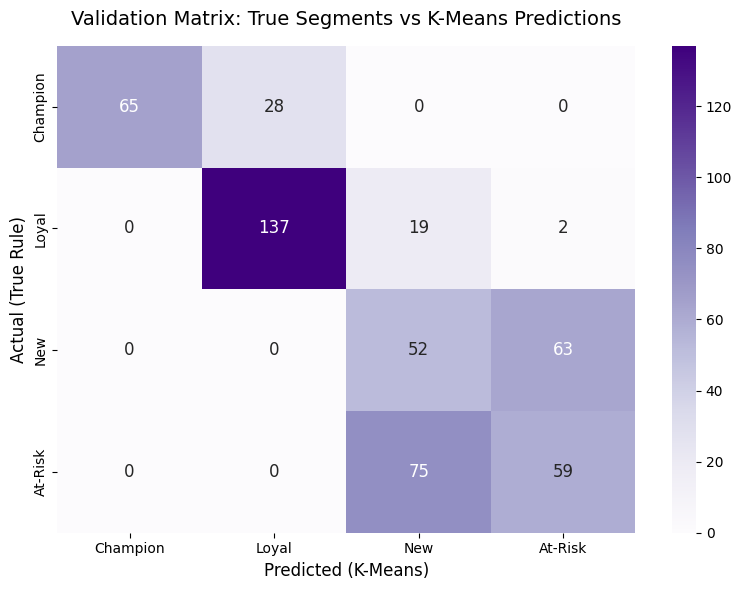

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าลำดับกลุ่มให้สวยงามเป็นระบบ
segment_order = ['Champion', 'Loyal', 'New', 'At-Risk']
ordered_matrix = validation_matrix.reindex(index=segment_order, columns=segment_order, fill_value=0)

# พล็อตกราฟ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ordered_matrix, annot=True, fmt='d', cmap='Purples', cbar=True, annot_kws={"size": 12})

plt.title('Validation Matrix: True Segments vs K-Means Predictions', fontsize=14, pad=15)
plt.xlabel('Predicted (K-Means)', fontsize=12)
plt.ylabel('Actual (True Rule)', fontsize=12)
plt.tight_layout()
plt.show()